<h1>IMDB Review Sentiment Analysis<h1>

Amir Lorvand </br>


The dataset is available on:<br/>
https://www.kaggle.com/datasets/yasserh/imdb-movie-ratings-sentiment-analysis/data </br>
The dataset contains 2 column: <br>


1.   Text: The review content.
2.   Label: The sentiment label (0: negative, 1: positive)



In [ ]:
import pandas as pd

# read the dataset
raw_data = pd.read_csv('....v')

In [ ]:
# inspect the dataset
raw_data.head()

,text,label
0,I grew up (b. 1965) watching and loving the Th...,0
1,"When I put this movie in my DVD player, and sa...",0
2,Why do people who do not know what a particula...,0
3,Even though I have great interest in Biblical ...,0
4,Im a die hard Dads Army fan and nothing will e...,1


In [ ]:
raw_data.shape

(40000, 2)

<h2>Data Cleaning<h2>

In [ ]:
# convert text column to lowercase
raw_data['text'] = raw_data['text'].str.lower()

As numbers are not an important factor in sentimental analysis for movie reviews, I decided to remove them.

In [ ]:
import re

# function to remove punctuation, special characters and numbers
def remove_punctuation(text):
  text = re.sub(r'[^\x00-\x7F]+', '', text) # remove emojis
  text = re.sub(r'\d+', '', text) # remove numbers
  text = re.sub(r'[^a-z\s]', '', text)
  return text

raw_data['text'] = raw_data['text'].apply(remove_punctuation)

In [ ]:
raw_data.head()

,text,label
0,i grew up b watching and loving the thunderbi...,0
1,when i put this movie in my dvd player and sat...,0
2,why do people who do not know what a particula...,0
3,even though i have great interest in biblical ...,0
4,im a die hard dads army fan and nothing will e...,1


Words like not, no, never, etc., have meaning in sentimental analysis. So, I decided to exclude them from stopwords.</br>
Since, on the first try, words like im or youre did not remove, I removed them by adding extra stop words.

In [ ]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
# stopwords that are important for sentimental analysis
excluding_words = {
    "not", "no", "never", "nt", "dont", "doesnt", "isnt", "wasnt",
    "couldnt", "cant", "cannot", "wont", "wouldnt", "werent", "werent"
}

# extra words that were added after the first try
extra_stopwords = {
    "im", "youre", "hes", "shes", "theyre", "ive", "youve", "weve", "theyve",
    "id", "youd", "hed", "shed", "theyd", "weve", "itll", "theyll", "whos",
    "whats", "hows", "theres", "heres", "thats"
}
stop_words_excluded = stop_words - excluding_words
stop_words_excluded.update(extra_stopwords)

# fuinction to remove stopwords
def remove_stopwords(text):
  words = text.split()
  words_splitted = [word for word in words if word not in stop_words_excluded]
  return ' '.join(words_splitted)

raw_data['text'] = raw_data['text'].apply(remove_stopwords)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [ ]:
import nltk
from nltk.tokenize import word_tokenize
nltk.download('punkt_tab')

# tokenisation
raw_data['text'] = raw_data['text'].apply(word_tokenize)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


The next step is lemmatisation, which converts each token into the base form. For example, eating into eat. It helps reduce vocabulary size while keeping meaning and improving word embadding. </br>
Lemmatisation was chosen over stemming because stemming sometimes produces incorrect forms, and lemmatisation ensures better linguistic meaning.</br>
Before lemmatisation, the PoS (part of speech) was done because lemmatisation required it. To specify the role of each word.

In [ ]:
from nltk.stem import WordNetLemmatizer
from nltk.corpus import wordnet
from nltk import pos_tag
nltk.download('averaged_perceptron_tagger_eng')
nltk.download('wordnet')
nltk.download('omw-1.4')

# function to apply PoS
def pos(text):
  if text.startswith('J'):
    return wordnet.ADJ
  elif text.startswith('V'):
    return wordnet.VERB
  elif text.startswith('N'):
    return wordnet.NOUN
  elif text.startswith('R'):
    return wordnet.ADV
  else:
    return wordnet.NOUN

lemmatiser = WordNetLemmatizer()

# apply PoS and lemmatisation
raw_data['text'] = raw_data['text'].apply(lambda words: [lemmatiser.lemmatize(word, pos(tag)) for word, tag in pos_tag(words)])

[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Package averaged_perceptron_tagger_eng is already up-to-
[nltk_data]       date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


In [ ]:
raw_data.head()

,text,label
0,"[grow, b, watch, loving, thunderbird, mat, sch...",0
1,"[put, movie, dvd, player, sit, coke, chip, exp...",0
2,"[people, not, know, particular, time, past, li...",0
3,"[even, though, great, interest, biblical, movi...",0
4,"[die, hard, dad, army, fan, nothing, ever, cha...",1


Since neural networks cannot process raw text, words should be converted into numerical format. I used GloVe for this task because it works better with medium size datasets, it is pre-trained, and I do not need a huge dataset.

In [ ]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# convert tokens into string with space
texts = raw_data['text'].apply(lambda x: ' '.join(x))

# tokenise the text again
tokeniser = Tokenizer()
tokeniser.fit_on_texts(texts)
word_index = tokeniser.word_index

# convert to numerical form
sequences = tokeniser.texts_to_sequences(texts)

# find the maximum length
max_length = max(len(sequence) for sequence in sequences)

# make all sequences to the same length
padded_sequences = pad_sequences(sequences, maxlen=max_length, padding='post')

In [ ]:
print('size of the vocabulary: ', len(word_index))
print('maximum sequence length: ', max_length)

size of the vocabulary:  144845
maximum sequence length:  1440


In [ ]:
# download GloVe
# !wget http://nlp.stanford.edu/data/glove.6B.zip
# !unzip glove.6B.zip

In [ ]:
# load gloVe into a dictionary
embedding_dimension = 100
glove_file_path = '/content/drive/MyDrive/Colab Notebooks/AI_CW_2/glove.6B.100d.txt'
embedding_index = {}
with open(glove_file_path, encoding='utf-8') as f:
  for line in f:
    values = line.split()
    word = values[0]
    coefs = np.asarray(values[1:], dtype='float32')
    embedding_index[word] = coefs

In [ ]:
# define embedding matrix
embedding_matrix = np.zeros((len(word_index) + 1, embedding_dimension))
for word, i in word_index.items():
  embedding_vector = embedding_index.get(word)
  if embedding_vector is not None:
    embedding_matrix[i] = embedding_vector

In [ ]:
print('shape of the embedding matrix', embedding_matrix.shape)

shape of the embedding matrix (144846, 100)


The embedding matrix's shape is 144,681 x 100. This means it has 144,681 unique words, and each word is represented as a 100-dimensional vector. This matrix is used to initialise the embedding layer in LSTM model.

Defining the LSTM model<br/>
First, I tried an LSTM model, but the accuracy was low (50%), so I tried Bidirectional LSTM and the accuracy increased.</br>
As this grid search is so computationally expensive, I only selected 10 random combinations to tune hyperparameters.

In [ ]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional, BatchNormalization
from tensorflow.keras.optimizers import Adam
from sklearn.model_selection import train_test_split
from itertools import product
import random
import os

# define a global seed
os.environ['PYTHONHASHSEED'] = '10'
os.environ['TF_DETERMINISTIC_OPS'] = '1'
random.seed(10)
np.random.seed(10)
tf.random.set_seed(10)

# define hyperparameters for the grid search
parameters = {
    'epochs': [10, 15],
    'learning_rate': [0.0001, 0.00001, 0.00005],
    'dense_neurons': [64, 128],
    'dropout_rate': [0.3, 0.5, 0.6],
    'batch_size': [32, 64]
}

# select 10 random combinations of hyperparameters
num_sample = 10
combinations = list(product(*parameters.values()))
random_combinitions = random.sample(combinations, num_sample)

# define variables to track the best model
best_model = None
best_accuracy = 0
best_parameters = {}
best_history = None

# split the dataset (train=64%, test=20%, validation=16%)
labels = np.array(raw_data['label'])
X_temp, X_test, y_temp, y_test = train_test_split(padded_sequences, labels, test_size=0.2, random_state=10)
X_train, X_validation, y_train, y_validation = train_test_split(X_temp, y_temp, test_size=0.2, random_state=10)

# run the grid search
for epochs, learning_rate, dense_neurons, dropout_rate, batch_size in random_combinitions:
  print(f'\n---Training model with Epochs={epochs}, LR={learning_rate}, Neurons={dense_neurons}, Dropout={dropout_rate}, Batch Size={batch_size}\n')

  class biLSTM_model(Model):
    def __init__(self, vocabulary_size, embedding_dimension, embedding_matrix, max_length):
      super(biLSTM_model, self).__init__()

      # embedding layer
      self.embedding = Embedding(
          input_dim=vocabulary_size,
          output_dim=embedding_dimension,
          weights=[embedding_matrix],
          trainable=False
      )

      # biLSTM layer
      self.bilstm =Bidirectional(LSTM(128, return_sequences=False))
      self.batch_normalisation = BatchNormalization()

      # dropout layer
      self.dropout = Dropout(dropout_rate)

      # dense layer
      self.dense = Dense(dense_neurons, activation='relu')

      # output ;ayer
      self.output_layer = Dense(1, activation='sigmoid')

    def call(self, input):
      x = self.embedding(input)
      x = self.bilstm(x)
      x = self.batch_normalisation(x)
      x = self.dropout(x)
      x = self.dense(x)
      return self.output_layer(x)

  vocabulary_size = len(word_index) + 1

  # define the model
  model = biLSTM_model(vocabulary_size, embedding_dimension, embedding_matrix, max_length)
  dummy_data = tf.zeros((1, max_length))
  _ = model(dummy_data) # initialise the model with dummy data

  # compile the model
  model.compile(loss='binary_crossentropy', optimizer=Adam(learning_rate=learning_rate), metrics=['accuracy'])

  # train the mode
  history = model.fit(X_train, y_train, batch_size=batch_size, epochs=epochs, validation_data=(X_validation, y_validation), verbose=1)

  # final validation accuracy
  val_accuracy = history.history['val_accuracy'][-1]

  # track the best model
  if val_accuracy > best_accuracy:
    best_accuracy = val_accuracy
    best_model = model
    best_parameters = {
        'epochs': epochs,
        'learning_rate': learning_rate,
        'dense_neurons': dense_neurons,
        'dropout_rate': dropout_rate,
        'batch_size': batch_size
    }
    best_history = history.history
    model.save('/content/drive/MyDrive/Colab Notebooks/AI_CW_2/best_model.h5')

print('BEST MODEL PARAMETERS\n:')
print(best_parameters)
print('ACCURACY OF THE MODEL: ' + str(best_accuracy))


---Training model with Epochs=10, LR=0.0001, Neurons=64, Dropout=0.6, Batch Size=32

Epoch 1/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 75s 90ms/step - accuracy: 0.6364 - loss: 0.6236 - val_accuracy: 0.7713 - val_loss: 0.4843
Epoch 2/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7743 - loss: 0.4854 - val_accuracy: 0.7848 - val_loss: 0.4536
Epoch 3/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7953 - loss: 0.4519 - val_accuracy: 0.8022 - val_loss: 0.4252
Epoch 4/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.8030 - loss: 0.4365 - val_accuracy: 0.8109 - val_loss: 0.4140
Epoch 5/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.8115 - loss: 0.4227 - val_accuracy: 0.8244 - val_loss: 0.3954
Epoch 6/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.8219 - loss: 0.4047 - val_accuracy: 0.8166 - val_loss: 0.4065
Epoch 7/10
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.8292 - loss: 0.3911 - val_accuracy: 0.8302 - val_loss: 0.3789
Epoc


---Training model with Epochs=15, LR=1e-05, Neurons=128, Dropout=0.3, Batch Size=32

Epoch 1/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 74s 90ms/step - accuracy: 0.5399 - loss: 0.6905 - val_accuracy: 0.6242 - val_loss: 0.6723
Epoch 2/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.6473 - loss: 0.6517 - val_accuracy: 0.7402 - val_loss: 0.5323
Epoch 3/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7478 - loss: 0.5316 - val_accuracy: 0.7588 - val_loss: 0.5101
Epoch 4/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7622 - loss: 0.5092 - val_accuracy: 0.7725 - val_loss: 0.4918
Epoch 5/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7680 - loss: 0.4994 - val_accuracy: 0.7767 - val_loss: 0.4821
Epoch 6/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7748 - loss: 0.4901 - val_accuracy: 0.7822 - val_loss: 0.4741
Epoch 7/15
800/800 ━━━━━━━━━━━━━━━━━━━━ 72s 90ms/step - accuracy: 0.7798 - loss: 0.4821 - val_accuracy: 0.7845 - val_loss: 0.4683
Epoc


---Training model with Epochs=10, LR=5e-05, Neurons=128, Dropout=0.6, Batch Size=64

Epoch 1/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 52s 122ms/step - accuracy: 0.6071 - loss: 0.6633 - val_accuracy: 0.7380 - val_loss: 0.5321
Epoch 2/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.7616 - loss: 0.5092 - val_accuracy: 0.7794 - val_loss: 0.4802
Epoch 3/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.7789 - loss: 0.4811 - val_accuracy: 0.7702 - val_loss: 0.4872
Epoch 4/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.7499 - loss: 0.5383 - val_accuracy: 0.7925 - val_loss: 0.4544
Epoch 5/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.7922 - loss: 0.4571 - val_accuracy: 0.7986 - val_loss: 0.4417
Epoch 6/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.7980 - loss: 0.4457 - val_accuracy: 0.8044 - val_loss: 0.4356
Epoch 7/10
400/400 ━━━━━━━━━━━━━━━━━━━━ 49s 123ms/step - accuracy: 0.8045 - loss: 0.4358 - val_accuracy: 0.8031 - val_loss: 0.43

Plot the result

250/250 ━━━━━━━━━━━━━━━━━━━━ 9s 34ms/step


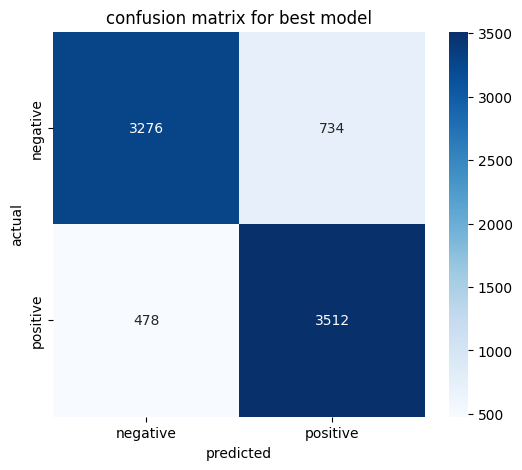

accuracy: 0.8485
precision: 0.8271314178049929
recall: 0.8802005012531329
F1 score: 0.8528411850412821


In [ ]:
from sklearn.metrics import confusion_matrix, recall_score, precision_score, f1_score, accuracy_score
import seaborn as sns
import matplotlib.pyplot as plt

# get predictions
y_hat = (best_model.predict(X_test) > 0.5).astype("int32")

# plot confusion matrix
conf_matrix = confusion_matrix(y_test, y_hat)
plt.figure(figsize=(6,5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=['negative', 'positive'], yticklabels=['negative', 'positive'])
plt.xlabel('predicted')
plt.ylabel('actual')
plt.title('confusion matrix for best model')
plt.show()

print('accuracy: ' + str(accuracy_score(y_test, y_hat)))
print('precision: ' + str(precision_score(y_test, y_hat)))
print('recall: ' + str(recall_score(y_test,y_hat)))
print('F1 score: ' + str(f1_score(y_test, y_hat)))

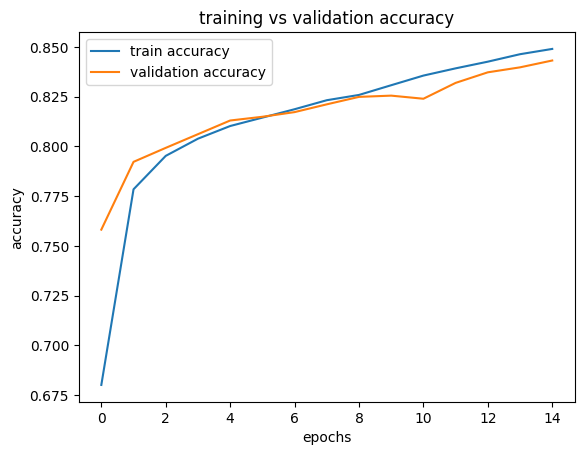

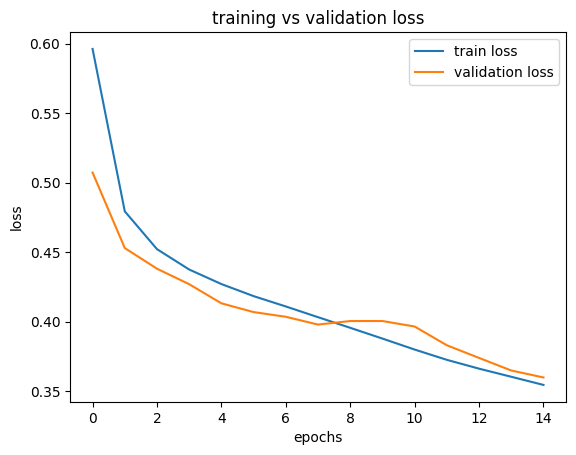

In [ ]:
if best_history is not None:
    # Plot Accuracy
    plt.plot(best_history['accuracy'], label='train accuracy')
    plt.plot(best_history['val_accuracy'], label='validation accuracy')
    plt.xlabel('epochs')
    plt.ylabel('accuracy')
    plt.legend()
    plt.title('training vs validation accuracy')
    plt.show()

    # Plot Loss
    plt.plot(best_history['loss'], label='train loss')
    plt.plot(best_history['val_loss'], label='validation loss')
    plt.xlabel('epochs')
    plt.ylabel('loss')
    plt.legend()
    plt.title('training vs validation loss')
    plt.show()